## adult income  cash study

In [3]:
import pandas as pd 

import matplotlib.pyplot as plt 

import seaborn as sns 

import numpy as np 

In [4]:
data = pd.read_csv('adult.csv')  
data.head() 

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## 1. Fetch Random Samples From Dataset(50%) 

In [5]:
data.sample(frac= 0.50) 

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
23441,52,Private,174421,Assoc-acdm,12,Divorced,Prof-specialty,Unmarried,White,Female,0,0,32,United-States,<=50K
42102,23,Private,210053,Some-college,10,Never-married,Other-service,Not-in-family,White,Female,0,0,28,United-States,<=50K
36037,32,Self-emp-not-inc,337696,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,<=50K
18502,57,State-gov,39380,HS-grad,9,Separated,Other-service,Not-in-family,White,Female,0,0,35,United-States,<=50K
13033,54,Private,186224,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39333,68,Private,170376,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
46003,60,Self-emp-not-inc,187794,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,3103,0,60,United-States,>50K
12344,18,Private,190325,11th,7,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
21060,23,Private,83891,HS-grad,9,Never-married,Sales,Own-child,Asian-Pac-Islander,Male,0,0,40,United-States,<=50K


# 2.Check Null Values 

In [6]:
data.isnull() 

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48838,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48839,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48840,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

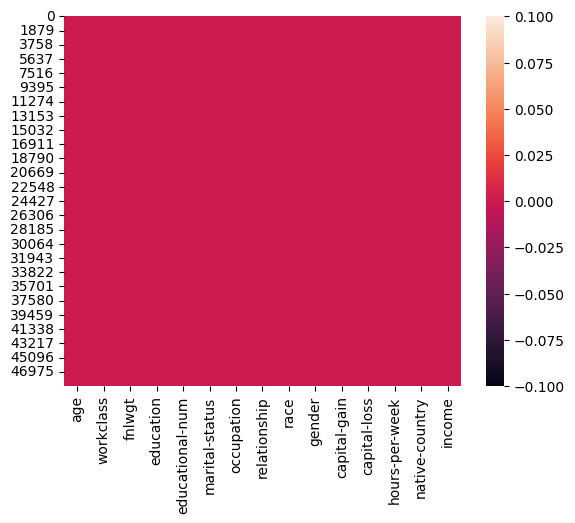

In [7]:
sns.heatmap(data.isnull()) 

# 3. Perform Data Cleaning [Replace '?' with NaN]

In [8]:
data.tail(10)  

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48832,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
48833,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
48834,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
48835,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
48836,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [9]:
data.isin(['?']).sum() 

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [10]:
data['workclass'] = data['workclass'].replace('?',np.nan)
data['occupation'] = data['occupation'].replace('?',np.nan)
data['native-country'] = data['native-country'].replace('?',np.nan)

In [11]:
data.isin(['?']).sum() 

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [12]:
data.isnull().sum() 

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

<Axes: >

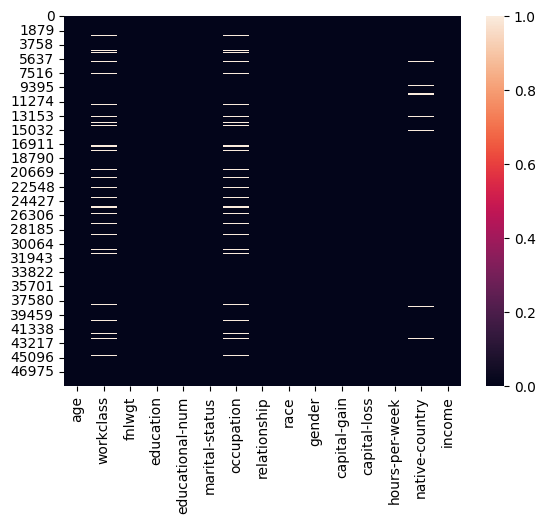

In [13]:
sns.heatmap(data.isnull()) 

# 4. Drop All Null Values 

In [14]:
data.dropna(how = 'any',inplace= True)  

<Axes: >

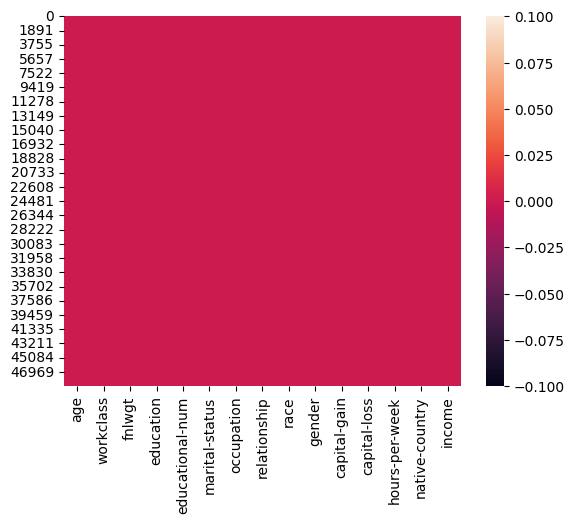

In [15]:
sns.heatmap(data.isnull()) 

In [16]:
data.shape

(45222, 15)

# 5. Check For Duplicate Data And Drop Them 

In [17]:
data.duplicated().sum() 

np.int64(47)

In [18]:
data = data.drop_duplicates() 

In [19]:
data.shape

(45175, 15)

# 6. Get Overall Statistic about Dataset 

In [20]:
data.describe(include= 'all') 

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
count,45175.000000,45175,4.517500e+04,45175,45175.000000,45175,45175,45175,45175,45175,45175.000000,45175.000000,45175.000000,45175,45175
unique,NaN,7,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Craft-repair,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33262,NaN,14770,NaN,21042,6010,18653,38859,30495,NaN,NaN,NaN,41256,33973
mean,38.556170,NaN,1.897388e+05,NaN,10.119314,NaN,NaN,NaN,NaN,NaN,1102.576270,88.687593,40.942512,NaN,NaN
std,13.215349,NaN,1.056524e+05,NaN,2.551740,NaN,NaN,NaN,NaN,NaN,7510.249876,405.156611,12.007730,NaN,NaN
min,17.000000,NaN,1.349200e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.173925e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783120e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,47.000000,NaN,2.379030e+05,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


# 7. Drop The Colunm Education-num, capital-gain, capital-loss 

In [21]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [22]:
data = data.drop(['educational-num','capital-gain','capital-loss'],axis = 1) 

In [23]:
data.columns 

Index(['age', 'workclass', 'fnlwgt', 'education', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'hours-per-week',
       'native-country', 'income'],
      dtype='object')

# 8. Find Total Number Of Person Having Age Between 17 to 48 
# (Inclusive) using Between Method 

In [24]:
data[data['age'].between(17,48)].shape[0] 

34858

# 9. How Many People Having Bechelors and Masters Degree 

In [25]:
sum((data['education'] == 'Bechelors') |  (data['education'] == 'Masters')) 

2513

In [26]:
sum(data['education'].isin(['Bechelors','Masters']))

2513

# 10. What is Distrubution of workclass column 

In [27]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'hours-per-week',
       'native-country', 'income'],
      dtype='object')

In [28]:
data['workclass'].describe()

count       45175
unique          7
top       Private
freq        33262
Name: workclass, dtype: object

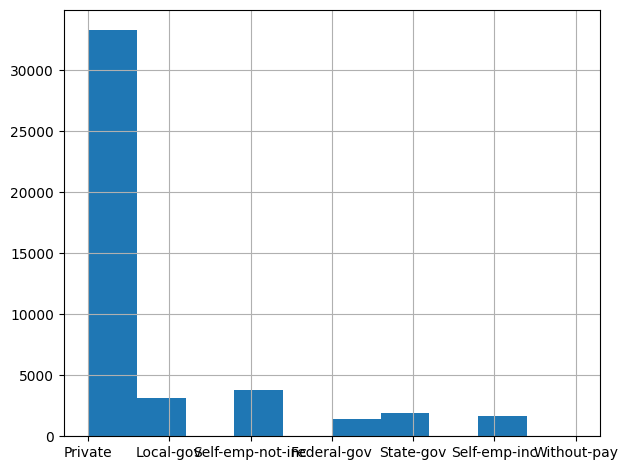

In [29]:
plt.Figure(figsize=(20,20))
data['workclass'].hist()
plt.tight_layout()
plt.show()

# 11. Bivariate Analysis 

<Axes: xlabel='income', ylabel='age'>

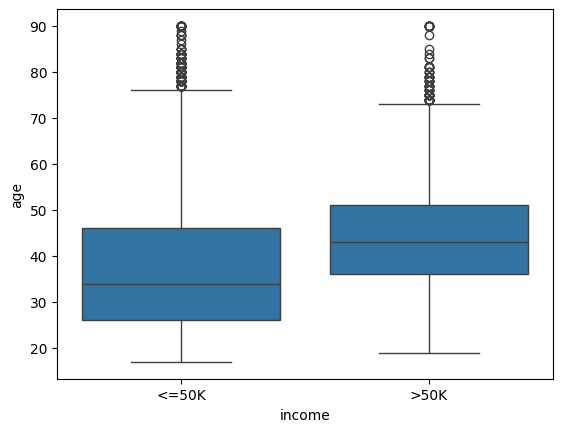

In [30]:
sns.boxplot(x='income',y='age',data=data)

# 12. Replace Salary Values ['<=50k','>50k'] with 0 and 1

In [31]:
data['income'].dtype

dtype('O')

In [32]:
def salary_change(sal):
    if sal == '<=50K':
        return 0
    else:
        return 1

In [33]:
data['Modify_income'] = data['income'].apply(salary_change)

In [34]:
data.head()

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income,Modify_income
0,25,Private,226802,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,>50K,1
3,44,Private,160323,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40,United-States,>50K,1
5,34,Private,198693,10th,Never-married,Other-service,Not-in-family,White,Male,30,United-States,<=50K,0


In [35]:
data.replace(to_replace=['<=50K','>50K'],value=[0,1],inplace= True)

C:\Users\KaziKudratAli\AppData\Local\Temp\ipykernel_10032\2534942718.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(to_replace=['<=50K','>50K'],value=[0,1],inplace= True)


In [36]:
data.head()

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income,Modify_income
0,25,Private,226802,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,0,0
1,38,Private,89814,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,0,0
2,28,Local-gov,336951,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,1,1
3,44,Private,160323,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40,United-States,1,1
5,34,Private,198693,10th,Never-married,Other-service,Not-in-family,White,Male,30,United-States,0,0


# 13. Which Working Class Geting Highest Salary? 

In [37]:
data.groupby('workclass')['Modify_income'].mean().sort_values(ascending= False).head(1)

workclass
Self-emp-inc    0.554407
Name: Modify_income, dtype: float64

# 14. How has better chance to get higher salary >50k Male or Female?

In [38]:
data.groupby('gender')['Modify_income'].mean().sort_values(ascending= False)

gender
Male      0.312609
Female    0.113692
Name: Modify_income, dtype: float64

# 15. Convert workclass column datatype to Category datatype    

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45175 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45175 non-null  int64 
 1   workclass       45175 non-null  object
 2   fnlwgt          45175 non-null  int64 
 3   education       45175 non-null  object
 4   marital-status  45175 non-null  object
 5   occupation      45175 non-null  object
 6   relationship    45175 non-null  object
 7   race            45175 non-null  object
 8   gender          45175 non-null  object
 9   hours-per-week  45175 non-null  int64 
 10  native-country  45175 non-null  object
 11  income          45175 non-null  int64 
 12  Modify_income   45175 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 4.8+ MB


In [40]:
data['workclass']= data['workclass'].astype('category') 

In [41]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 45175 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             45175 non-null  int64   
 1   workclass       45175 non-null  category
 2   fnlwgt          45175 non-null  int64   
 3   education       45175 non-null  object  
 4   marital-status  45175 non-null  object  
 5   occupation      45175 non-null  object  
 6   relationship    45175 non-null  object  
 7   race            45175 non-null  object  
 8   gender          45175 non-null  object  
 9   hours-per-week  45175 non-null  int64   
 10  native-country  45175 non-null  object  
 11  income          45175 non-null  int64   
 12  Modify_income   45175 non-null  int64   
dtypes: category(1), int64(5), object(7)
memory usage: 4.5+ MB


## 16. Which education level earns more?

In [43]:
data.groupby('education')['Modify_income'].mean()

education
10th            0.067048
11th            0.054972
12th            0.074783
1st-4th         0.036364
5th-6th         0.049217
7th-8th         0.066910
9th             0.056213
Assoc-acdm      0.264101
Assoc-voc       0.257406
Bachelors       0.420161
Doctorate       0.733456
HS-grad         0.163439
Masters         0.554318
Preschool       0.014286
Prof-school     0.754140
Some-college    0.201072
Name: Modify_income, dtype: float64

<Axes: ylabel='education'>

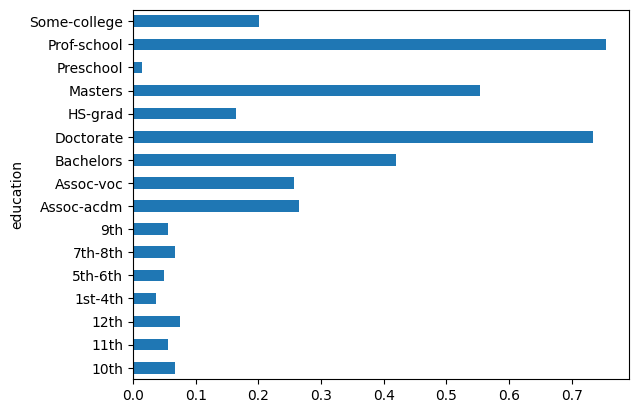

In [50]:
data.groupby('education')['Modify_income'].mean().plot(kind='barh')


## 17. Gender income comparison

In [45]:
data.groupby('gender')['income'].value_counts()

gender  income
Female  0         13011
        1          1669
Male    0         20962
        1          9533
Name: count, dtype: int64

## 18. Average age of adults

In [47]:
data['age'].mean()

np.float64(38.55617044825678)

## 19. Average work hours per week

In [ ]:
data['hours-per-week'].mean()

## 20. Average Work hours Per week for each occupation

In [52]:
data.groupby('occupation')['hours-per-week'].mean()

occupation
Adm-clerical         37.713098
Armed-Forces         41.714286
Craft-repair         42.268719
Exec-managerial      44.976421
Farming-fishing      46.866441
Handlers-cleaners    37.850856
Machine-op-inspct    40.744013
Other-service        34.672425
Priv-house-serv      32.834783
Prof-specialty       42.285286
Protective-serv      42.834872
Sales                40.733395
Tech-support         39.782946
Transport-moving     44.746114
Name: hours-per-week, dtype: float64